# Trening Multimodalnego Silnika Wyszukiwania (CLIP / Two-Tower)

Niniejszy notatnik dokumentuje proces projektowania, implementacji oraz treningu multimodalnego modelu uczenia maszynowego (Image-to-Text) przeznaczonego do wyszukiwania semantycznego. 

Projekt stanowi etap badawczo-rozwojowy (Feature Extraction, Alignment & Fine-Tuning) poprzedzający wdrożenie produkcyjne modelu w architekturze mikroserwisowej z bazą wektorową.

Jako framework bazowy wybrano **PyTorch** ze względu na jego imperatywny paradygmat obliczeniowy, pythonic API oraz elastyczność przy konstruowaniu asymetrycznych architektur multimodalnych. Celem eksperymentu jest wytrenowanie zoptymalizowanego modelu typu **CLIP** (*Contrastive Language-Image Pre-training*), zdolnego do mapowania obrazów i tekstu do wspólnej przestrzeni wektorowej.


**Główne założenia architektury:**
* **Zbiór Danych (Dataset):** Zbiór *Animals-90* z platformy Kaggle obejmujący 90 zróżnicowanych klas gatunków zwierząt wraz z wygenerowanymi przez model typu BLIP opisami tekstowymi.
* **Wieża Wizyjna:** Pre-trenowany `EfficientNet-B0` (ekstrakcja cech przestrzennych, zamrożone wagi bazowe).
* **Wieża Tekstowa:** Pre-trenowany `DistilBERT` ze strategią Mean Pooling i obsługą maski uwagi (Attention Mask).
* **Funkcja straty:** Contrastive Loss (InfoNCE) z uczonym parametrem temperatury.
* **Optymalizacja batcha:** Autorski `HardNegativeBatchSampler` grupujący próbki klasami w celu redukcji zjawiska fałszywych negatywów.
* **Strategia Treningowa:** Dwuetapowy transfer learning (Faza 1: zbieżność głowic projekcyjnych, Faza 2: selektywny fine-tuning ostatnich bloków enkoderów).
* **Baza Wektorowa i Wyszukiwanie (Vector Store):** Indeks `FAISS` (*Facebook AI Similarity Search*) w konfiguracji `IndexFlatIP` (Inner Product) do niskolatencyjnego wyszukiwania podobieństwa kosinusowego w gęstych wektorach (*Dense Retrieval*).


## 1. Import potrzebnych narzędzi oraz bibliotek

In [1]:
# Ukrycie ostrzezen 
import warnings
warnings.filterwarnings("ignore")
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# importowaniem bibliotek PyTorch i Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Sampler
from torchvision import models
from torchvision.transforms import v2
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split   

#Biblioteki narzędziowe
import os
import json
import yaml
import random
import faiss
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from typing import List, Tuple

#Ustawienie seed'a dla gwarancji powtarzalności wyników eksperymentów
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

# Wczytanie pliku YAML ze zmiennymi 
with open("../configs/config_model_training.yaml", "r") as f:
    cfg = yaml.safe_load(f)

#Przypisanie najwaniejszych zmiennych

IMAGES_PATH = cfg['data']['images_path']
CAPTIONS_PATH = cfg['data']['captions_path']



## 2. Eksploracja Zbioru Danych (EDA)

In [2]:
dataset_dir = Path(IMAGES_PATH)
valid_extensions = {".jpg", ".jpeg", ".png"}

images_path = []
all_classes = []

for file_path in dataset_dir.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
        images_path.append(str(file_path))
        all_classes.append(file_path.parent.name)

unique_classes = sorted(set(all_classes))

print(f"Liczba poprawnych zdjęć: {len(images_path)}")
print(f"Liczba wykrytych klas: {len(unique_classes)}")

Liczba poprawnych zdjęć: 5400
Liczba wykrytych klas: 90


### 2.1 Wczytanie podpisów oraz Wizualizacja

Liczba wczytanych podpisów: 5400


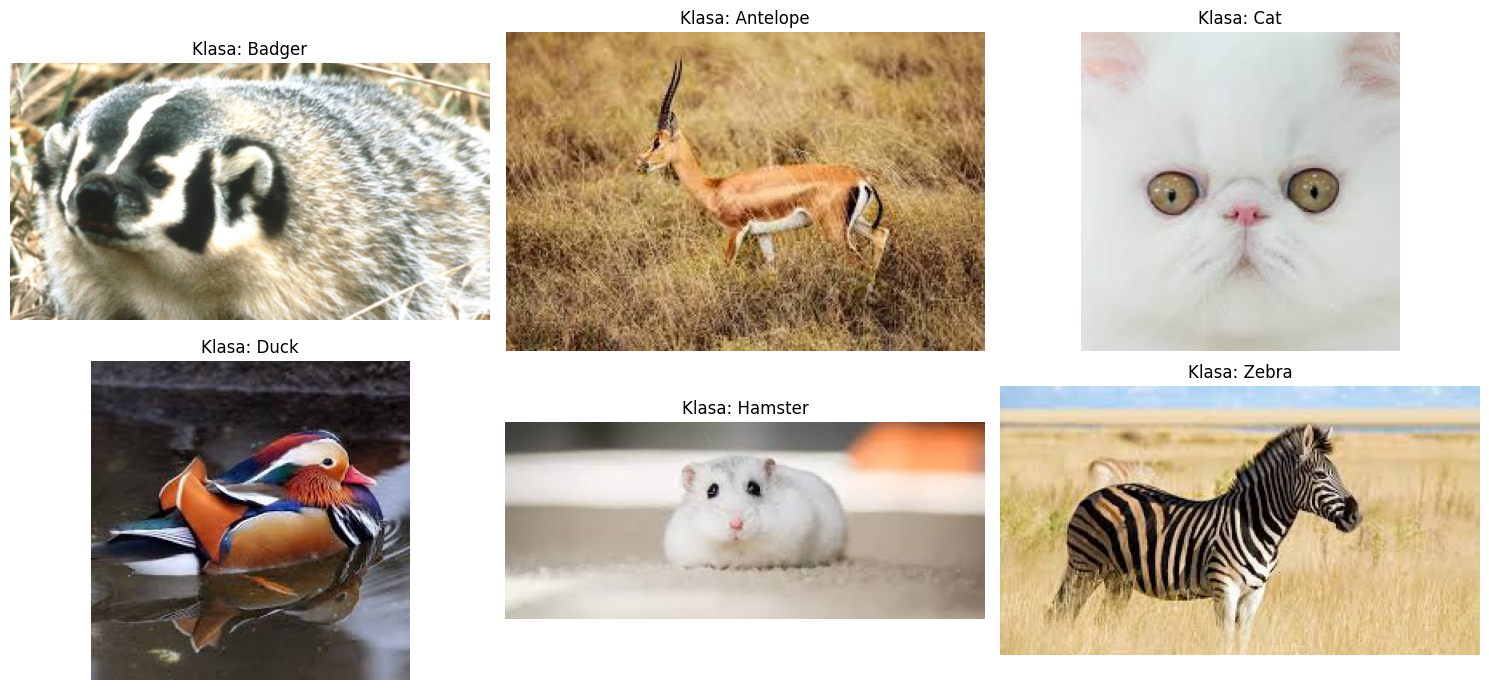

In [3]:
with open(CAPTIONS_PATH, "r", encoding="utf-8") as file:
    captions = json.load(file)

print(f"Liczba wczytanych podpisów: {len(captions)}")

sample_paths = random.sample(images_path, 6)

plt.figure(figsize=(15, 7))
for i, path_str in enumerate(sample_paths):
    image_path = Path(path_str)
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)

    plt.title(f"Klasa: {image_path.parent.name.capitalize()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Dataset i Pipeline Danych

### 3.1 Zdefiniowanie klasy zbioru danych

In [4]:
captions_dict = {Path(item['path']).name: item['caption'] for item in captions}

class CLIPDataset(Dataset):
    def __init__(self, all_images_paths, captions_dict, tokenizer, max_text_length, transform=None):
        self.images_paths = all_images_paths
        self.captions = captions_dict
        self.tokenizer = tokenizer
        self.max_text_length = max_text_length
        self.targets = [Path(path).parent.name for path in self.images_paths]
        self.classes = sorted(set(self.targets))
        self.class_to_idx = {class_name: i for i, class_name in enumerate(self.classes)}

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, index):
        image_path = self.images_paths[index]
        img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        file_name = Path(image_path).name
        text = str(self.captions[file_name])

        tokens = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)
        class_name = Path(image_path).parent.name
        idx_class = self.class_to_idx[class_name]

        return img, input_ids, attention_mask, idx_class

tokenizer = AutoTokenizer.from_pretrained(cfg['model']['text_encoder'])


### 3.2 Zdefioniowanie klasy modelu wielomodalnego

In [5]:
class ImageEmbeddingTower(nn.Module):
    def __init__(self, num_dims: int):
        super().__init__()
        self.num_dims = num_dims

        model_weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=model_weights)

        for params in self.backbone.parameters():
            params.requires_grad = False

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()


        self.embedding_head = nn.Sequential(
            nn.Linear(self.num_features, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.embedding_head(features)

class TextEmbeddingTower(nn.Module):
    def __init__(self, num_dims: int):
        super().__init__()
        self.num_dims = num_dims

        self.text_encoder_model = AutoModel.from_pretrained("distilbert-base-uncased", attn_implementation="eager")
        self.num_bert_feature = self.text_encoder_model.config.hidden_size

        for params in self.text_encoder_model.parameters():
            params.requires_grad = False

        self.text_projection = nn.Sequential(
            nn.Linear(self.num_bert_feature, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def mean_pooling(self, last_hidden_state: torch.Tensor, attention_mask: torch.Tensor):

        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        )

        sum_embedding = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embedding / sum_mask

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        text_outputs = self.text_encoder_model(input_ids, attention_mask)
        pooled_output = self.mean_pooling(last_hidden_state=text_outputs.last_hidden_state, attention_mask=attention_mask)

        projected_embd = self.text_projection(pooled_output)

        return projected_embd

class CLIPModel(nn.Module):
    def __init__(self, num_dims: int):
        super().__init__()
        self.image_tower = ImageEmbeddingTower(num_dims)
        self.text_tower = TextEmbeddingTower(num_dims)

    def forward(self, x: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        image_embedding = self.image_tower(x)
        text_embedding = self.text_tower(input_ids, attention_mask)

        img_norm = F.normalize(image_embedding, p=2, dim=-1)
        text_norm = F.normalize(text_embedding, p=2, dim=-1)
        return img_norm, text_norm
    


class MultiPositiveCLIPLoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()

        self.logit_scale = nn.Parameter(
            torch.tensor(np.log(1 / init_temp), dtype=torch.float32)
        )

    def forward(self, img_emb, text_emb, labels):

        img_emb = F.normalize(img_emb, dim=-1)
        text_emb = F.normalize(text_emb, dim=-1)


        logit_scale = self.logit_scale.exp().clamp(max=100)

        logits_per_image = logit_scale * (img_emb @ text_emb.T)

        logits_per_text = logits_per_image.T


        labels = labels.view(-1, 1)
        mask = (labels == labels.T).float()

        def masked_loss(logits, mask):
            log_probs = F.log_softmax(logits, dim=1)

            positive_log_probs = (mask * log_probs).sum(dim=1)
            num_positives = mask.sum(dim=1)

            loss = -positive_log_probs / num_positives

            return loss.mean()

        loss_i2t = masked_loss(
            logits_per_image,
            mask
        )

        loss_t2i = masked_loss(
            logits_per_text,
            mask.T
        )

        return (loss_i2t + loss_t2i) / 2



criterion = MultiPositiveCLIPLoss()
model = CLIPModel(cfg['model']['embedding_dim'])

optimizer = torch.optim.AdamW([
    {"params": model.parameters()},
    {"params": criterion.parameters()}
], lr=cfg['training']['learning_rate_head'])

device = cfg['training']['device']
model.to(device)
criterion.to(device)

        

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7054.23it/s]


MultiPositiveCLIPLoss()

## 4. Implementacja autorskiego samplera

In [6]:
class HardNegativeBatchSampler(Sampler):
    def __init__(self, labels: List[int], batch_size: int, samples_per_class: int):
        self.labels = labels
        self.batch_size = batch_size
        self.samples_per_class = samples_per_class

        self.classes_per_batch = batch_size // samples_per_class

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.class_to_indices[label].append(idx)

        self.classes = list(self.class_to_indices.keys())
        self.num_batches = len(labels) // batch_size

    def __iter__(self):
        for _ in range(self.num_batches):
            batch_indices = []
            selected_classes = random.sample(self.classes, self.classes_per_batch)

            for cls in selected_classes:
                indices = self.class_to_indices[cls]
                if len(indices) >= self.samples_per_class:
                    sampled = random.sample(indices, self.samples_per_class)
                else:
                    sampled = random.choices(indices, k=self.samples_per_class)

                batch_indices.extend(sampled)

            random.shuffle(batch_indices)

            yield batch_indices

    def __len__(self):
        return self.num_batches

In [7]:

test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

dataset = CLIPDataset(
    all_images_paths=images_path,
    captions_dict=captions_dict,
    tokenizer=tokenizer,
    max_text_length=cfg['model']['max_text_length']
)


train_paths, temp_path, train_targets, temp_targets = train_test_split(
    dataset.images_paths,
    dataset.targets,
    test_size=0.30,
    random_state=42,
    stratify=dataset.targets
)

val_paths, test_paths = train_test_split(
    temp_path,
    test_size=0.5,
    random_state=42,
    stratify=temp_targets
)

train_dataset = CLIPDataset(train_paths, captions_dict, tokenizer, cfg['model']['max_text_length'])
val_dataset   = CLIPDataset(val_paths, captions_dict, tokenizer, cfg['model']['max_text_length'], transform=test_transform)
test_dataset  = CLIPDataset(test_paths, captions_dict, tokenizer, cfg['model']['max_text_length'], transform=test_transform)

custom_sampler = HardNegativeBatchSampler(
    labels=train_dataset.targets,
    batch_size=cfg['training']['batch_size'],
    samples_per_class=cfg['training']['samples_per_class']
)

train_dataloader = DataLoader(
    train_dataset,
    batch_sampler=custom_sampler,
    num_workers=0
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=cfg['training']['batch_size'],
    shuffle=False,
    num_workers=0
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=cfg['training']['batch_size'],
    shuffle=False,
    num_workers=0
)


## 5. Pętla treningowa z metrykami


In [8]:
def train_epoch(model: torch.nn.Module, criterion: torch.nn.Module, optimizer: torch.optim.Optimizer, loader: torch.utils.data.DataLoader, device: torch.device):
    model.train()

    model.image_tower.backbone.features[:-2].eval()

    total_loss, total_r1, total_r3, total_mmr = 0.0, 0.0, 0.0, 0.0

    progress_bar = tqdm(loader, desc="Training Epoch: ")

    for image, input_ids, attention_mask, labels in progress_bar:
        image = image.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        img_emb, text_emb = model(image, input_ids, attention_mask)
        loss = criterion(img_emb, text_emb, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            img_emb_norm = F.normalize(img_emb, dim=-1)
            text_emb_norm = F.normalize(text_emb, dim=-1)
            logits_per_image = img_emb_norm @ text_emb_norm.T

            labels_2d = labels.view(-1, 1)
            mask = (labels_2d == labels_2d.T)

            sorted_indices = logits_per_image.argsort(dim=1, descending=True)
            sorted_mask = mask.gather(1, sorted_indices)

            r1 = sorted_mask[:, 0].float().mean().item()

            k = min(3, logits_per_image.shape[1])
            r3 = sorted_mask[:, :k].any(dim=1).float().mean().item()

            first_positive_idx = sorted_mask.float().argmax(dim=1)
            mrr = (1.0 / (first_positive_idx + 1.0)).mean().item()


            

        total_loss += loss.item()
        total_r1 += r1
        total_r3 += r3
        total_mmr += mrr

        progress_bar.set_postfix({
            'Loss': f"{loss.item():.4f}", 
            'Top1': f"{r1:.2f}",
            'Top3': f"{r3:.2f}",
            'MMR': f"{mrr:.2f}"
        })

        epoch_metrics = {
                "loss": total_loss / len(loader),
                "top1_accuracy": total_r1 / len(loader),
                "top3_accuracy": total_r3 / len(loader),
                "mean_reciprocal_rank": total_mmr / len(loader)
            }

    return epoch_metrics

In [9]:
def val_epoch(model: torch.nn.Module, criterion: torch.nn.Module, loader: torch.utils.data.DataLoader, device: torch.device):
    model.eval()
    total_loss, total_r1, total_r3, total_mmr = 0.0, 0.0, 0.0, 0.0
    
    progress_bar = tqdm(loader, desc="Validation Epoch: ")

    with torch.no_grad():
        for image, input_ids, attention_mask, labels in progress_bar:
            image = image.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            img_emb, text_emb = model(image, input_ids, attention_mask)
            loss = criterion(img_emb, text_emb, labels)

            img_emb_norm = F.normalize(img_emb, dim=-1)
            text_emb_norm = F.normalize(text_emb, dim=-1)
            logits_per_image = img_emb_norm @ text_emb_norm.T

            labels_2d = labels.view(-1, 1)
            mask = (labels_2d == labels_2d.T)

            sorted_indices = logits_per_image.argsort(dim=1, descending=True)
            sorted_mask = mask.gather(1, sorted_indices)

            r1 = sorted_mask[:, 0].float().mean().item()

            k = min(3, logits_per_image.shape[1])
            r3 = sorted_mask[:, :k].any(dim=1).float().mean().item()

            first_positive_idx = sorted_mask.float().argmax(dim=1)
            mrr = (1.0 / (first_positive_idx + 1.0)).mean().item()

            total_loss += loss.item()
            total_r1 += r1
            total_r3 += r3
            total_mmr += mrr
    return {
        "loss": total_loss / len(loader),
        "top1_accuracy": total_r1 / len(loader),
        "top3_accuracy": total_r3 / len(loader),
        "mean_reciprocal_rank": total_mmr / len(loader)  
    }
    

In [10]:
epochs = cfg['training']['epochs']
best_loss = float('inf')
epochs_without_update = 0
patience = cfg['training']['patience']
history = {"loss": [], "r1": [], "r3": [], "lr": [], "mmr": []}


for epoch in range(epochs):
    metrics_train = train_epoch(model, criterion, optimizer, train_dataloader, device)
    metrics_val = val_epoch(model, criterion, val_dataloader, device)

    epoch_loss = metrics_train['loss']
    r1 = metrics_train['top1_accuracy']
    r3 = metrics_train['top3_accuracy']
    mmr = metrics_train['mean_reciprocal_rank']

    epoch_loss_val = metrics_val['loss']
    epoch_r1_val = metrics_val['top1_accuracy']
    epoch_r3_val = metrics_val['top3_accuracy']
    epoch_mmr_val = metrics_val['mean_reciprocal_rank']

    history['loss'].append(epoch_loss)
    history['r1'].append(r1)
    history['r3'].append(r3)
    history['mmr'].append(mmr)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | R@1: {r1:.2%} | R@3: {r3:.2%} | MMR {mmr:.2%}")
    print(f"Val Loss: {epoch_loss_val:.4f} | Val R@1: {epoch_r1_val:.2%} | Val R@3: {epoch_r3_val:.2%} | Val MMR: {epoch_mmr_val:.2%}")
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if epoch_loss_val < best_loss:
        best_loss = epoch_loss_val
        epochs_without_update = 0
        torch.save(model.state_dict(), "../models/best_model.pth")
    else:
        epochs_without_update += 1
        if epochs_without_update >= patience:
            print(f"Brak poprawy przez {patience} kolejnych epok. Najlepszy uzyskany Loss: {best_loss:.4f}")
            break


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  3.73it/s]


Epoch 01/15 | Loss: 2.5803 | R@1: 48.28% | R@3: 70.95% | MMR 62.25%
Val Loss: 1.6658 | Val R@1: 61.13% | Val R@3: 83.65% | Val MMR: 73.61%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.11it/s]


Epoch 02/15 | Loss: 1.7704 | R@1: 78.58% | R@3: 93.54% | MMR 86.52%
Val Loss: 1.3183 | Val R@1: 71.97% | Val R@3: 90.75% | Val MMR: 82.04%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.13it/s]


...

Epoch 13/15 | Loss: 1.1707 | R@1: 95.68% | R@3: 99.68% | MMR 97.60%
Val Loss: 0.8355 | Val R@1: 86.18% | Val R@3: 95.91% | Val MMR: 91.27%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  3.92it/s]


Epoch 14/15 | Loss: 1.1745 | R@1: 95.21% | R@3: 99.63% | MMR 97.35%
Val Loss: 0.8197 | Val R@1: 86.54% | Val R@3: 96.03% | Val MMR: 91.59%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.15it/s]


Epoch 15/15 | Loss: 1.1299 | R@1: 96.29% | R@3: 99.74% | MMR 97.98%
Val Loss: 0.8090 | Val R@1: 86.66% | Val R@3: 96.15% | Val MMR: 91.67%


In [11]:
def plot_loss_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Loss', color='blue')
    plt.title('Loss w trakcie treningu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

def plot_accuracy_history(history):
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 3, 1)
    plt.plot(history['r1'], label='Top-1 Accuracy', color='green')
    plt.title('Top-1 Accuracy w trakcie treningu')
    plt.xlabel('Epoka')
    plt.ylabel('Top-1 Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history['r3'], label='Top-3 Accuracy', color='orange')
    plt.title('Top-3 Accuracy w trakcie treningu')
    plt.xlabel('Epoka')
    plt.ylabel('Top-3 Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history['mmr'], label='MMR', color='red')
    plt.title('Mean Reciprocal Rank w trakcie treningu')
    plt.xlabel('Epoka')
    plt.ylabel('MMR')
    plt.legend()

    

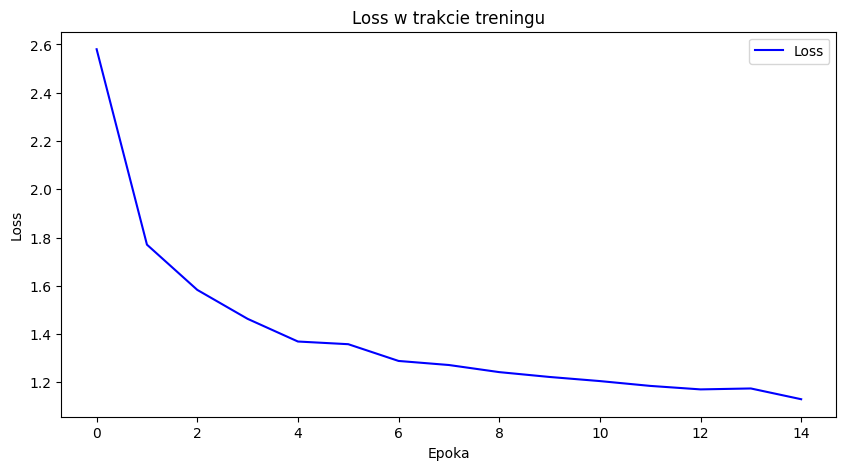

In [12]:
plot_loss_history(history)

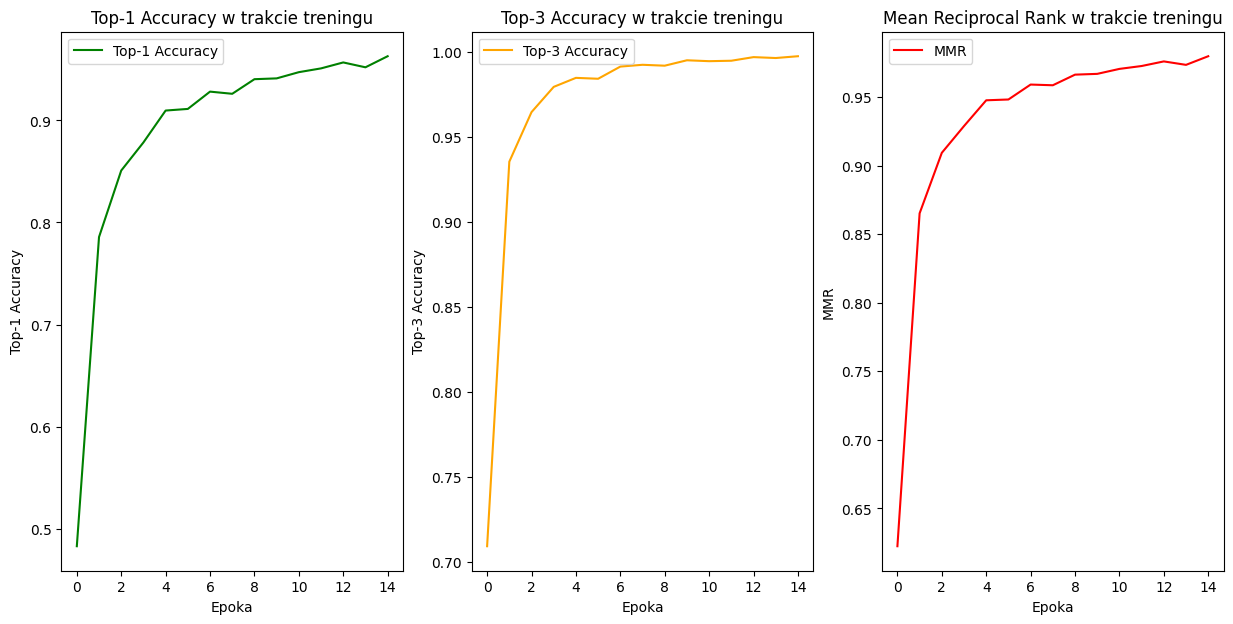

In [13]:
plot_accuracy_history(history)

In [14]:
for params in model.image_tower.backbone.features[-2:].parameters():
    params.requires_grad = True

for layer in model.text_tower.text_encoder_model.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

backbone_params = []
head_params = []

for name, param in model.image_tower.backbone.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

for name, param in model.text_tower.text_encoder_model.transformer.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

head_params.extend(list(model.image_tower.embedding_head.parameters()))
head_params.extend(list(model.text_tower.text_projection.parameters()))

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": cfg['training']['learning_rate_backbone'], "weight_decay": 1e-2},
    {"params": head_params, "lr": cfg['training']['weight_decay_head'], "weight_decay": cfg['training']['weight_decay_backbone']},
    {"params": [criterion.logit_scale], "lr": cfg['training']['weight_decay_head']}
])



In [15]:
epochs = cfg['training'].get('epochs_f2', 5)
best_loss = float('inf')
epochs_without_update = 0
patience = cfg['training']['patience']
history = {"loss": [], "r1": [], "r3": [], "lr": [], "mmr": []}


for epoch in range(epochs):
    metrics_train = train_epoch(model, criterion, optimizer, train_dataloader, device)
    metrics_val = val_epoch(model, criterion, val_dataloader, device)

    epoch_loss = metrics_train['loss']
    r1 = metrics_train['top1_accuracy']
    r3 = metrics_train['top3_accuracy']
    mmr = metrics_train['mean_reciprocal_rank']

    epoch_loss_val = metrics_val['loss']
    epoch_r1_val = metrics_val['top1_accuracy']
    epoch_r3_val = metrics_val['top3_accuracy']
    epoch_mmr_val = metrics_val['mean_reciprocal_rank']

    history['loss'].append(epoch_loss)
    history['r1'].append(r1)
    history['r3'].append(r3)
    history['mmr'].append(mmr)

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | R@1: {r1:.2%} | R@3: {r3:.2%} | MMR: {mmr:.2%}")
    print(f"Val Loss: {epoch_loss_val:.4f} | Val R@1: {epoch_r1_val:.2%} | Val R@3: {epoch_r3_val:.2%} | Val MMR: {epoch_mmr_val:.2%}")
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if epoch_loss_val < best_loss:
        best_loss = epoch_loss_val
        epochs_without_update = 0
        torch.save(model.state_dict(), "../models/best_model.pth")
    else:
        epochs_without_update += 1
        if epochs_without_update >= patience:
            print(f"   Brak poprawy przez {patience} kolejnych epok. Najlepszy uzyskany Loss: {best_loss:.4f}")
            break


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.15it/s]


Epoch 01/5 | Loss: 1.1138 | R@1: 96.53% | R@3: 99.71% | MMR: 98.03%
Val Loss: 0.7412 | Val R@1: 87.62% | Val R@3: 96.88% | Val MMR: 92.37%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.09it/s]


Epoch 02/5 | Loss: 1.0521 | R@1: 96.53% | R@3: 99.66% | MMR: 98.06%
Val Loss: 0.6764 | Val R@1: 89.06% | Val R@3: 97.00% | Val MMR: 93.39%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.16it/s]


Epoch 03/5 | Loss: 1.0225 | R@1: 96.88% | R@3: 99.74% | MMR: 98.25%
Val Loss: 0.6643 | Val R@1: 89.78% | Val R@3: 97.48% | Val MMR: 93.86%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.09it/s]


Epoch 04/5 | Loss: 0.9864 | R@1: 97.78% | R@3: 99.81% | MMR: 98.78%
Val Loss: 0.6419 | Val R@1: 89.18% | Val R@3: 97.48% | Val MMR: 93.56%


Validation Epoch: 100%|██████████| 26/26 [00:06<00:00,  4.10it/s]


Epoch 05/5 | Loss: 0.9768 | R@1: 97.11% | R@3: 99.97% | MMR: 98.44%
Val Loss: 0.6196 | Val R@1: 90.50% | Val R@3: 97.72% | Val MMR: 94.21%


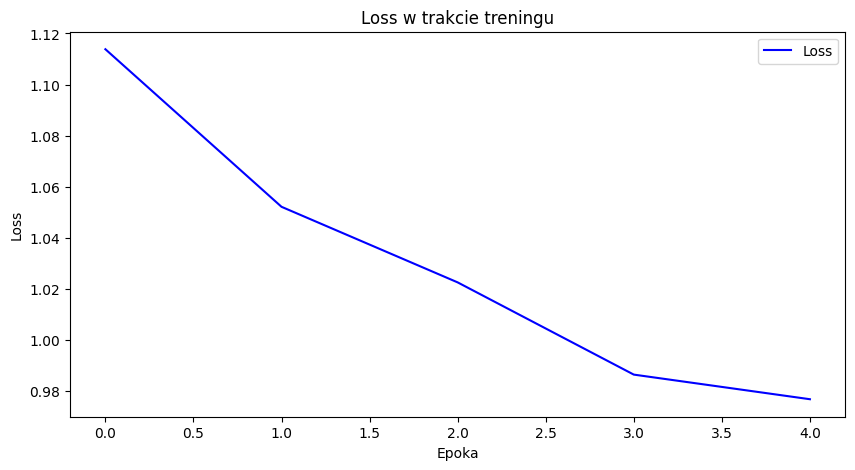

In [16]:
plot_loss_history(history)

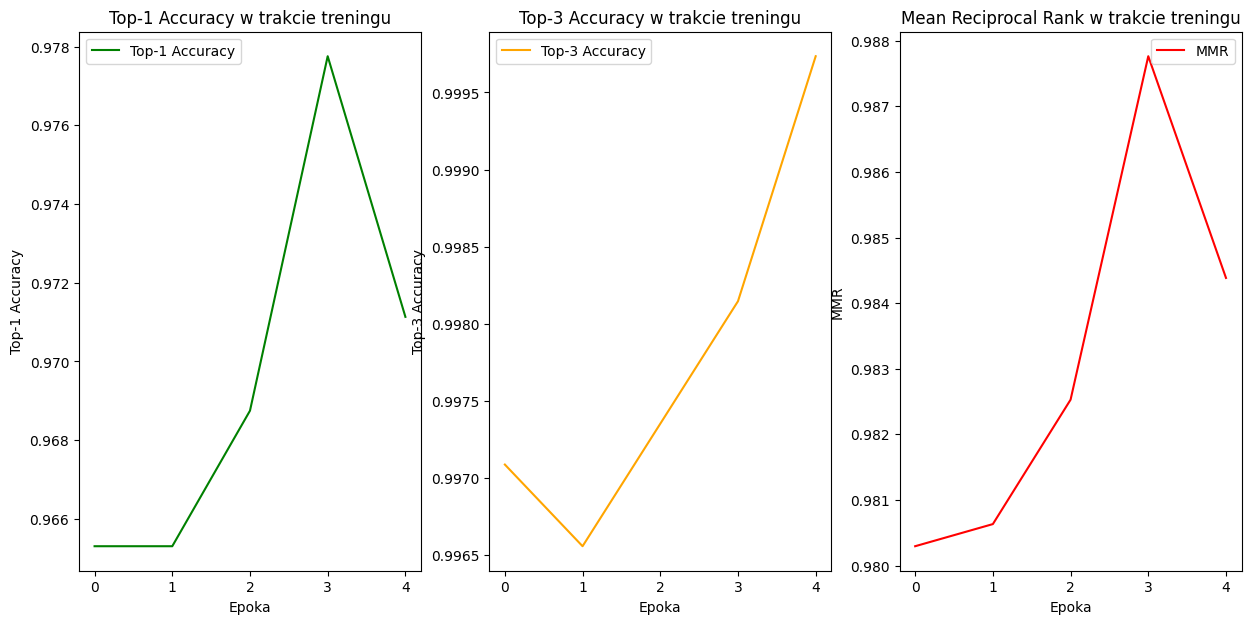

In [17]:
plot_accuracy_history(history)

In [18]:
class ImageInferenseDataset(Dataset):
    def __init__(self, image_paths: List[str], transform: v2.Compose):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, index):
        img = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(img)

    
test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def generate_clip_dataset(model: torch.nn.Module, image_paths: List[str], transform: v2.Compose, device: torch.device, batch_size: int):
    model.eval()

    dataset = ImageInferenseDataset(image_paths, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    database = []

    with torch.no_grad():
        for batch_imgs in tqdm(loader, desc="Ekstracja Embeddingow: "):
            batch_imgs = batch_imgs.to(device)

            img_emb = model.image_tower(batch_imgs)
            img_emb = F.normalize(img_emb, p=2, dim=-1)

            database.append(img_emb)
    return torch.cat(database, dim=0)

model.load_state_dict(torch.load("../models/best_model.pth"))
vec_base = generate_clip_dataset(model, images_path, test_transform, device, batch_size=cfg['training']['batch_size'])
    

Ekstracja Embeddingow: 100%|██████████| 169/169 [00:25<00:00,  6.59it/s]


### Budowa i zapis indeksów FAISS

In [19]:
embedding_np = vec_base.cpu().numpy().astype('float32')
dim = cfg['model']['embedding_dim']

index = faiss.IndexFlatIP(dim)
index.add(embedding_np)

print(f"Liczba wektorów w indeksie FAISS: {index.ntotal}")

faiss.write_index(index, "../data/database/animals_index.faiss")

image_path_clean = [str(p) for p in images_path]
with open("../data/database/images_path.json", "w", encoding="utf-8") as f:
    json.dump(image_path_clean, f)


Liczba wektorów w indeksie FAISS: 5400


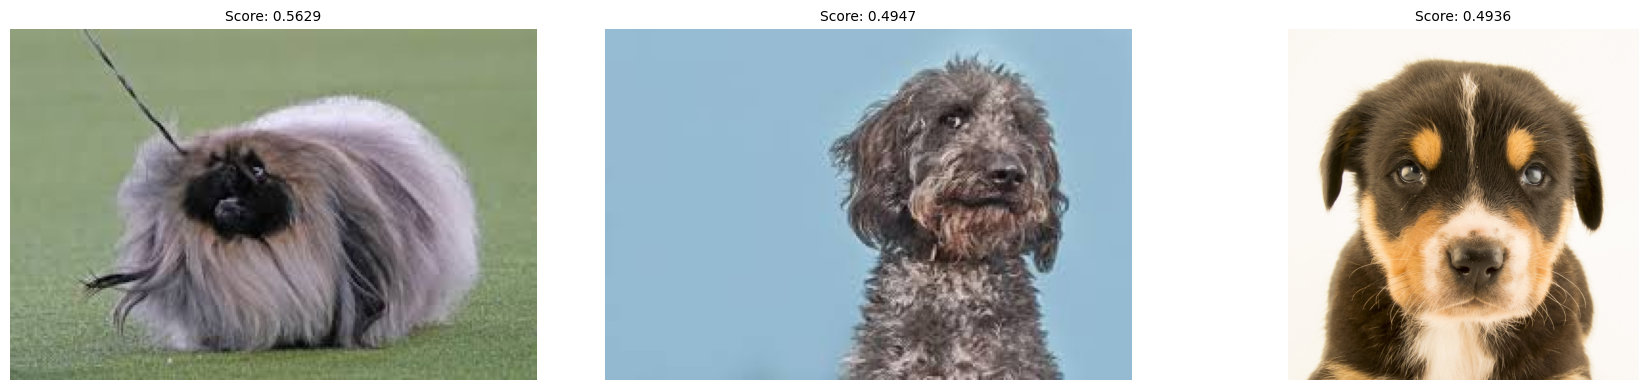

In [20]:
def search_image_by_text(query_text: str, 
                         database: torch.Tensor, 
                         images_path: List[str], 
                         tokenizer: AutoTokenizer, 
                         model: torch.nn.Module, 
                         device: torch.device = cfg['training']['device'], 
                         top_k: int = 3,
                         max_length: int = 256):

    model.eval()

    tokens = tokenizer(
        query_text,
        max_length=max_length,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(device)


    with torch.no_grad():
        text_emb = model.text_tower(tokens['input_ids'], tokens['attention_mask'])
        text_emb = F.normalize(text_emb, p=2, dim=-1)

        database_device = database.to(device)
        scores = (text_emb.to(database_device) @ database.T).squeeze(0)

        k = min(top_k, database.shape[0])
        top_values, top_indices = torch.topk(scores, k=k)

        matched_path = [str(images_path[idx.item()]) for idx in top_indices]
        matched_scores = [round(score.item(), 4) for score in top_values]

        return matched_path, matched_scores

result, scores = search_image_by_text("a really cute fluffy puppy looking at the camera", vec_base, images_path, tokenizer, model, device)

fig, axes = plt.subplots(1, len(result), figsize=(18, 4))
for ax, path, score in zip(axes, result, scores):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Score: {score}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()
        
